## Import what we need

In [3]:
import scipy.io as sio
import nibabel as nib  
import os
import numpy as np 
import matplotlib.pyplot as plt  
import seaborn as sns  
from nilearn import plotting, surface, datasets
from nilearn.image import resample_to_img 
from nilearn import plotting  
import pandas as pd 
from matplotlib import cm

## Step 1: We first project to Tian and Yeo network 

-- you don't really have to run this as we already have it --

In [5]:
data = sio.loadmat('output_HMM\Brain_state\Mean_states.mat')
state_means = data['z_mean']  

In [6]:
# load Tian subcortical network 
tian_template = nib.load('input_data/Tian_Subcortex_S1_3T_2009cAsym.nii.gz')
tian_data = tian_template.get_fdata()
affine = tian_template.affine

output_dir = "output_HMM\Brain_state\output_states_tian"
os.makedirs(output_dir, exist_ok=True)

nroi_tian = 16 
for i in range(state_means.shape[0]):
    state_data = np.zeros(tian_data.shape)
    
    for roi in range(1, nroi_tian + 1):
        state_data[tian_data == roi] = state_means[i, roi - 1]
    
    state_img = nib.Nifti1Image(state_data, affine)

    nib.save(state_img, os.path.join(output_dir, f'state{i+1}_tian_raw.nii.gz'))


In [7]:
# load Yeo 2011 network
yeo_template = nib.load('input_data/Yeo2011_17Networks_MNI152_FreeSurferConformed1mm.nii.gz')
yeo_data = yeo_template.get_fdata()
affine = yeo_template.affine

output_dir = "output_HMM\Brain_state\output_states_yeo"
os.makedirs(output_dir, exist_ok=True)

nroi_yeo = 17 

for i in range(state_means.shape[0]):
    state_data = np.zeros(yeo_data.shape)
    
    for roi in range(1, nroi_yeo + 1):
        state_data[yeo_data == roi] = state_means[i, nroi_tian + roi - 1]  # Note, we start index after Tian
    
    state_img = nib.Nifti1Image(state_data, affine)

    nib.save(state_img, os.path.join(output_dir, f'state{i+1}_yeo_raw.nii.gz'))


## Step 2: Graph Activation

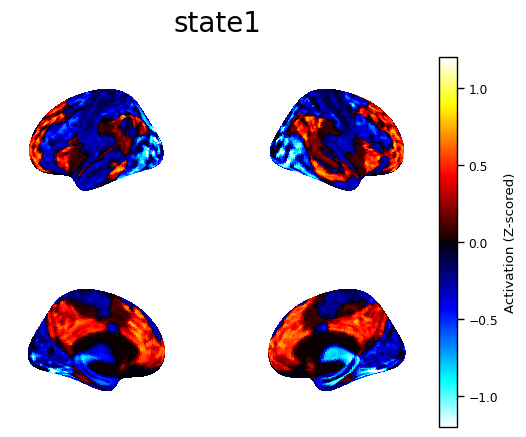

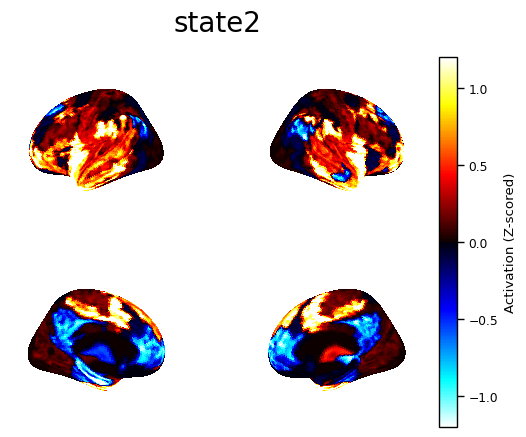

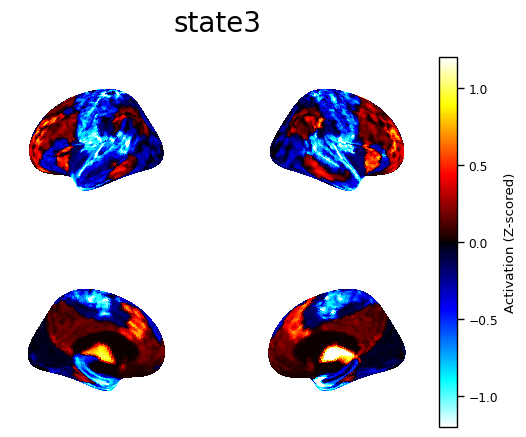

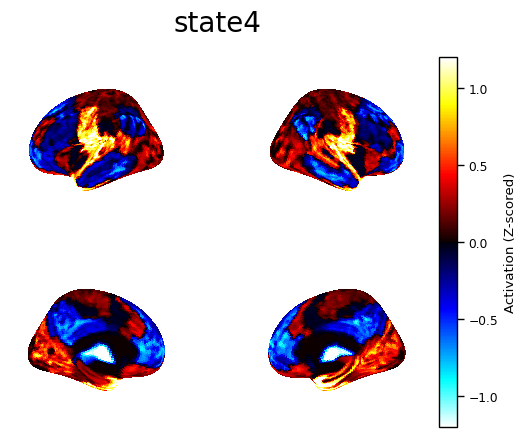

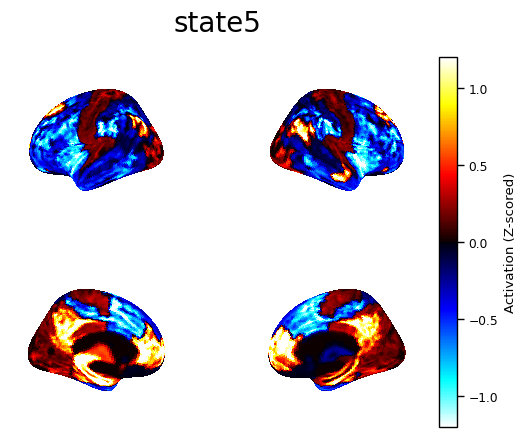

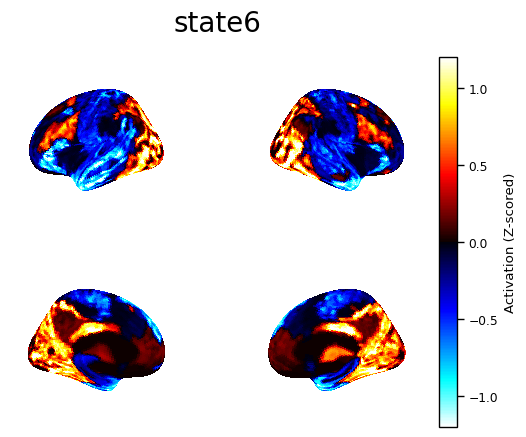

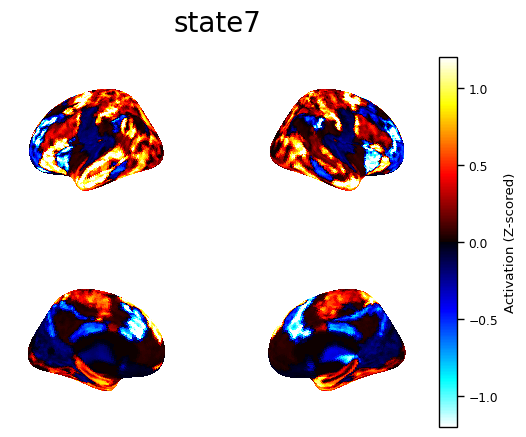

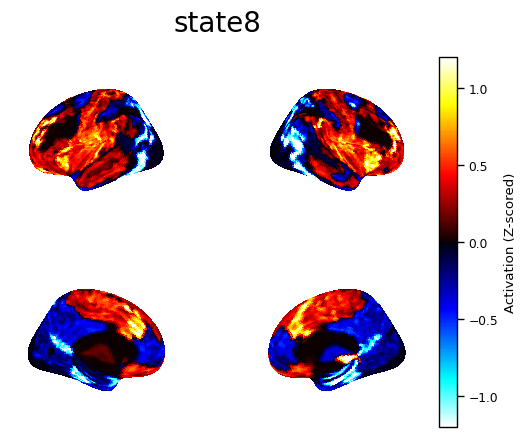

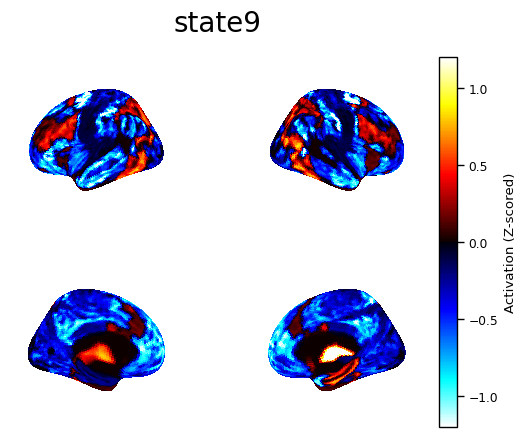

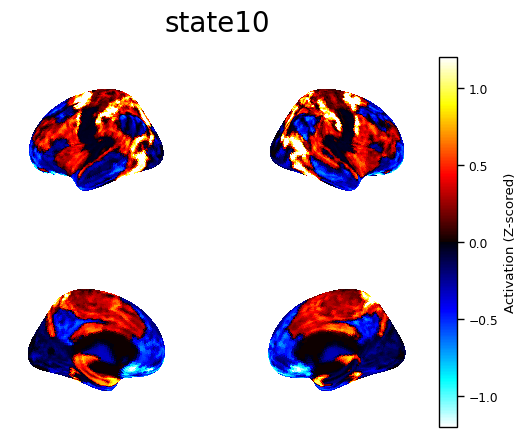

In [8]:
fsaverage = datasets.fetch_surf_fsaverage(mesh='fsaverage5')

tian_template = nib.load('input_data/Tian_Subcortex_S1_3T_2009cAsym.nii.gz')
yeo_template = nib.load('input_data/Yeo2011_17Networks_MNI152_FreeSurferConformed1mm.nii.gz')

yeo_resampled = resample_to_img(yeo_template, tian_template, interpolation='nearest')
yeo_data_resampled = yeo_resampled.get_fdata()
tian_data = tian_template.get_fdata()
affine = tian_template.affine

statename = ['state1', 'state2', 'state3','state4','state5','state6','state7','state8','state9','state10']

output_dir_tian = "output_HMM\Brain_state\output_states_tian"
output_dir_yeo = "output_HMM\Brain_state\output_states_yeo"

for stt in range(1, 11):  # 10 states
    # Load network
    tian_img = nib.load(os.path.join(output_dir_tian, f'state{stt}_tian_raw.nii.gz'))
    tian_data = tian_img.get_fdata()
    yeo_img = nib.load(os.path.join(output_dir_yeo, f'state{stt}_yeo_raw.nii.gz'))
    yeo_data = yeo_img.get_fdata()
    yeo_resampled_img = resample_to_img(yeo_img, tian_img, interpolation='nearest')
    yeo_data_resampled = np.squeeze(yeo_resampled_img.get_fdata())

    # Combine tian and yeo
    combined_data = tian_data + yeo_data_resampled

    combined_img = nib.Nifti1Image(combined_data, affine)

    surface_left = surface.vol_to_surf(combined_img, fsaverage.pial_left)
    surface_right = surface.vol_to_surf(combined_img, fsaverage.pial_right)

    sns.set_context('paper')
    fig, ((a, b), (c, d)) = plt.subplots(2, 2, subplot_kw={'projection': '3d'})

    plotting.plot_surf_stat_map(fsaverage.infl_left, surface_left, hemi='left',
                                view='lateral', bg_map=fsaverage.sulc_left, cmap='cold_hot',
                                vmax=1.2, symmetric_cbar=1, colorbar=False, axes=a)
    plotting.plot_surf_stat_map(fsaverage.infl_right, surface_right, hemi='right',
                                view='lateral', bg_map=fsaverage.sulc_right, cmap='cold_hot',
                                vmax=1.2, symmetric_cbar=1, colorbar=False, axes=b)
    plotting.plot_surf_stat_map(fsaverage.infl_left, surface_left, hemi='left',
                                view='medial', bg_map=fsaverage.sulc_left, cmap='cold_hot',
                                vmax=1.2, symmetric_cbar=1, colorbar=False, axes=c)
    plotting.plot_surf_stat_map(fsaverage.infl_right, surface_right, hemi='right',
                                view='medial', bg_map=fsaverage.sulc_right,  cmap='cold_hot',
                                vmax=1.2, symmetric_cbar=1, colorbar=False, axes=d)
    
    cbar = fig.colorbar(plt.cm.ScalarMappable(cmap='cold_hot', norm=plt.Normalize(vmin=-1.2, vmax=1.2)),
                    ax=[a, b, c, d], orientation='vertical', fraction=0.07, pad=0.04)
    cbar.set_label('Activation (Z-scored)')    

    plt.suptitle(statename[stt-1], fontsize=20)
    plt.show()


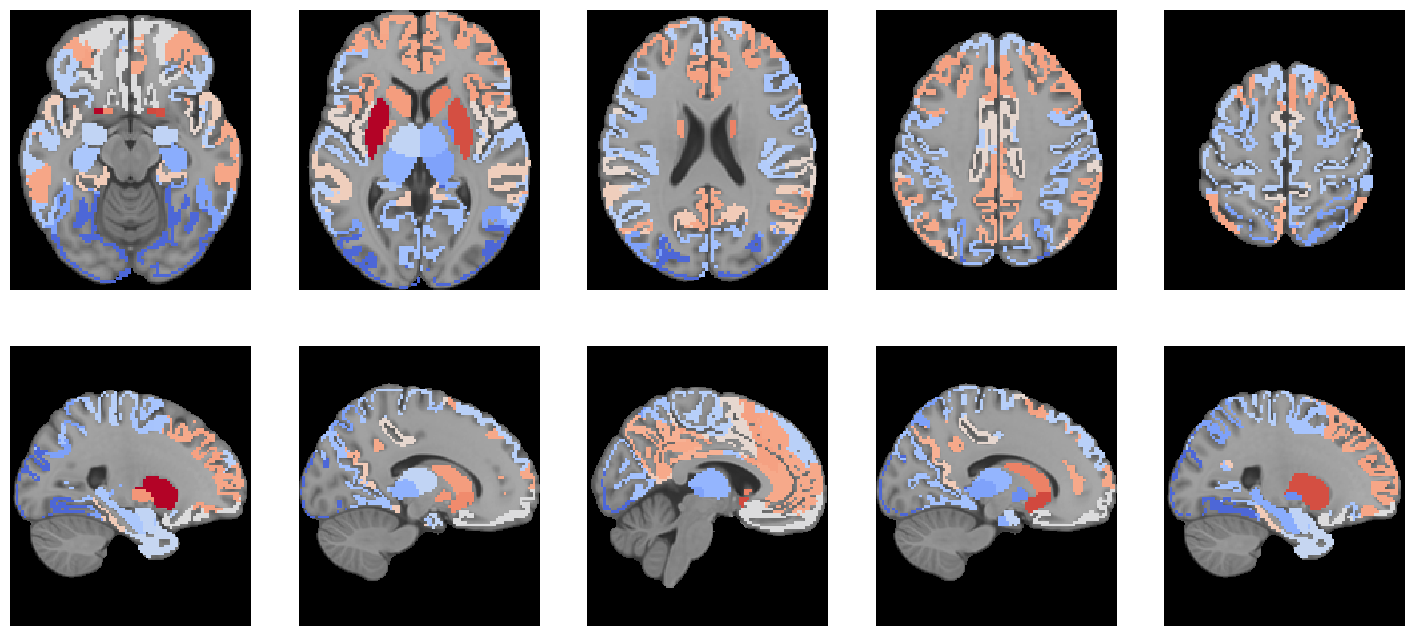

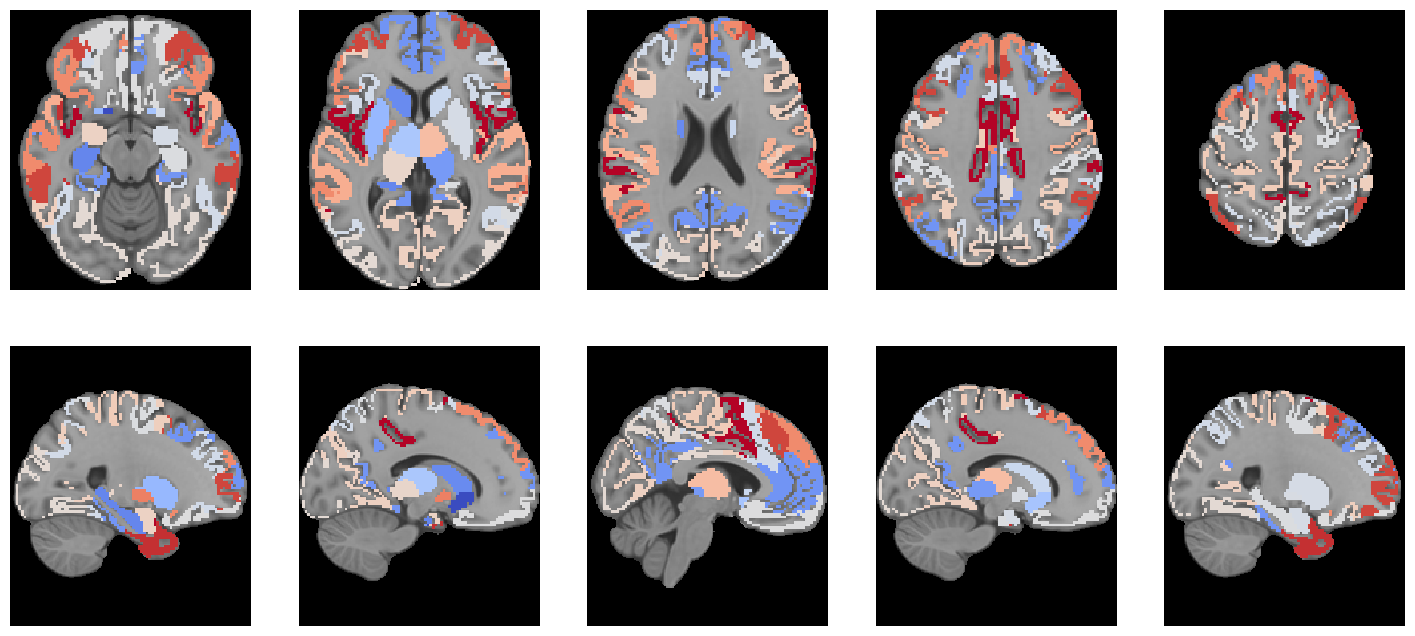

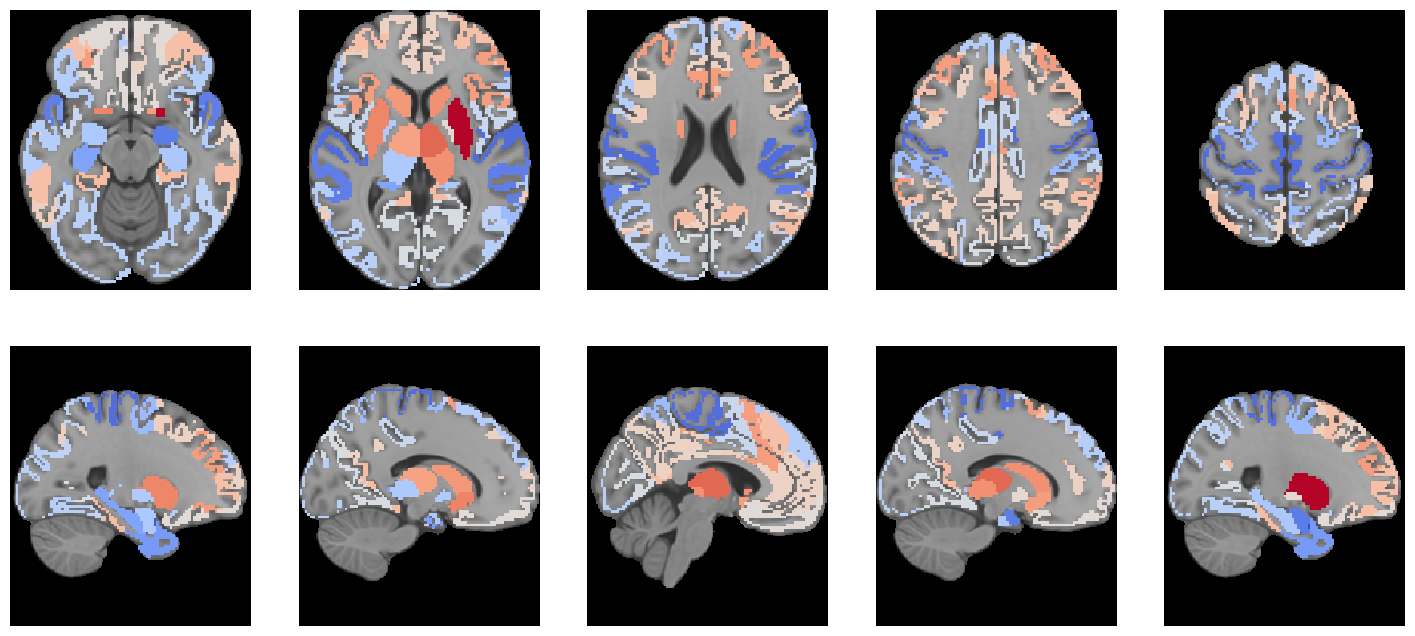

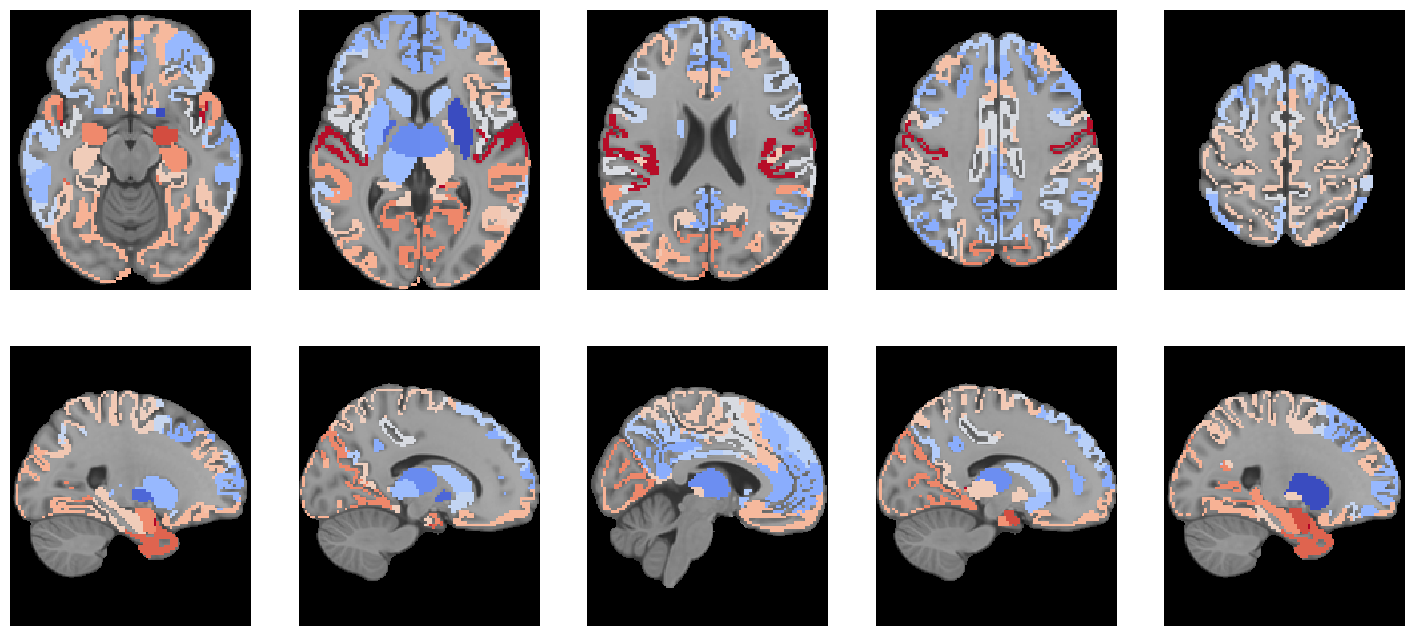

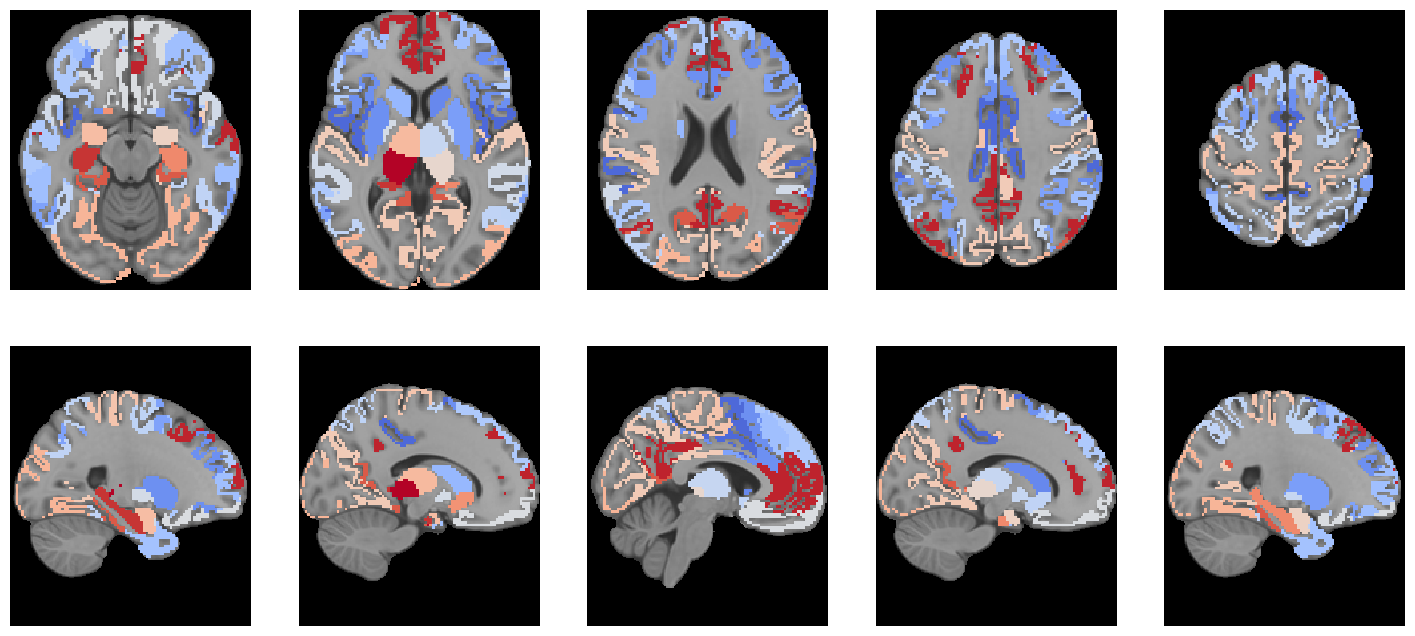

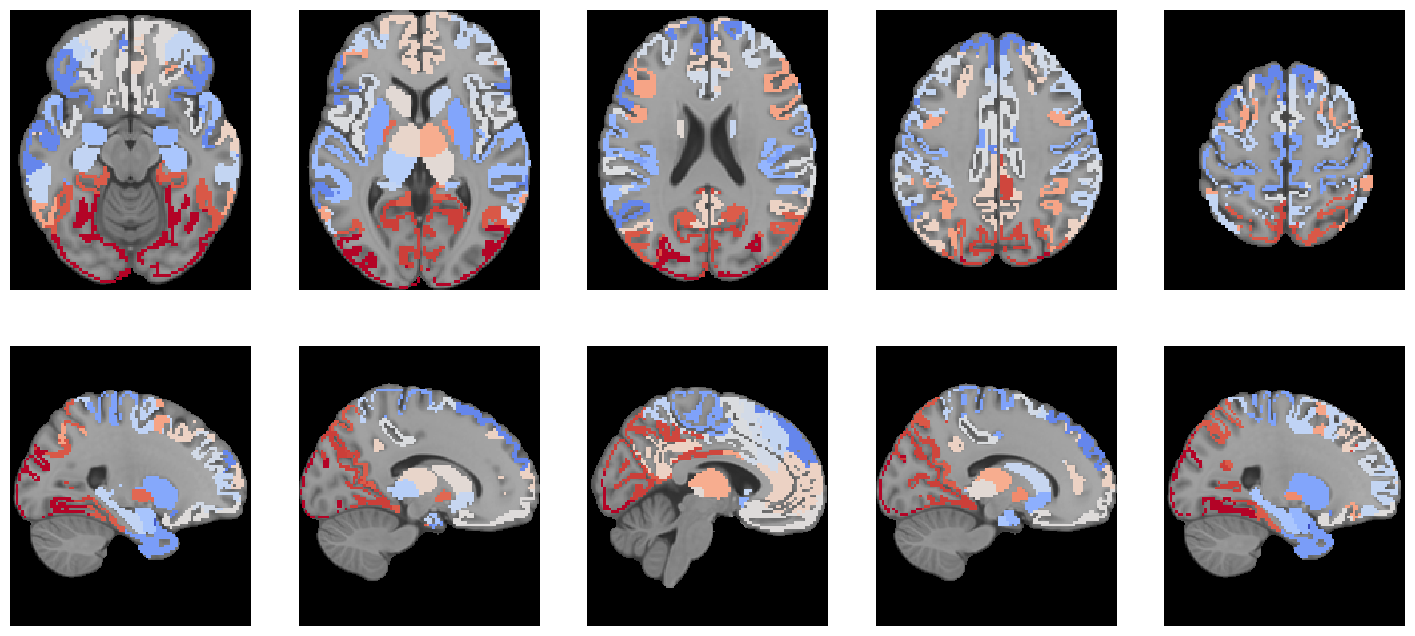

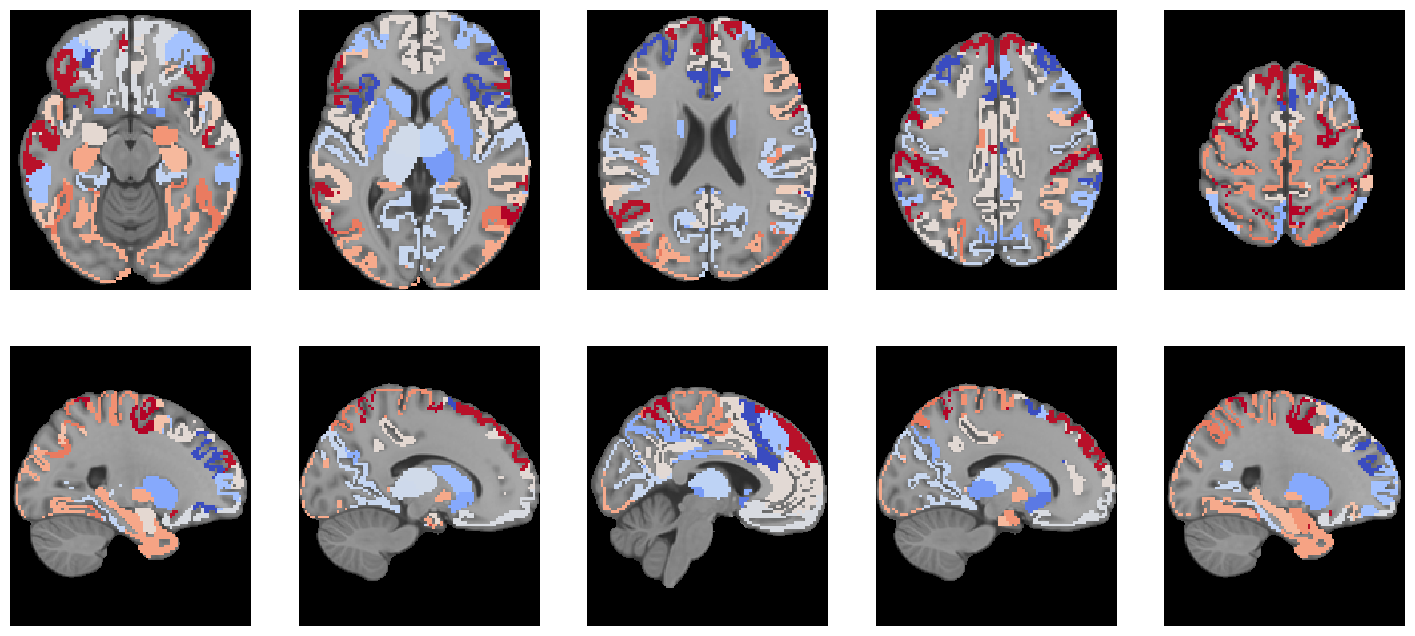

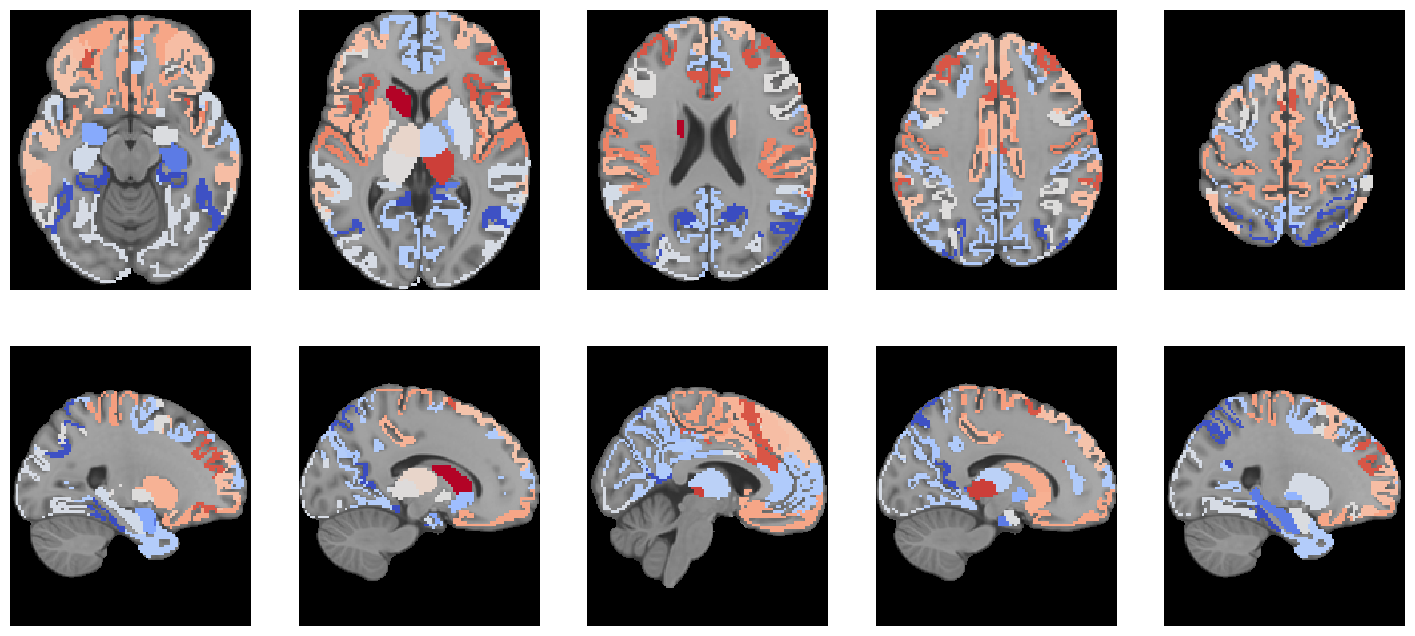

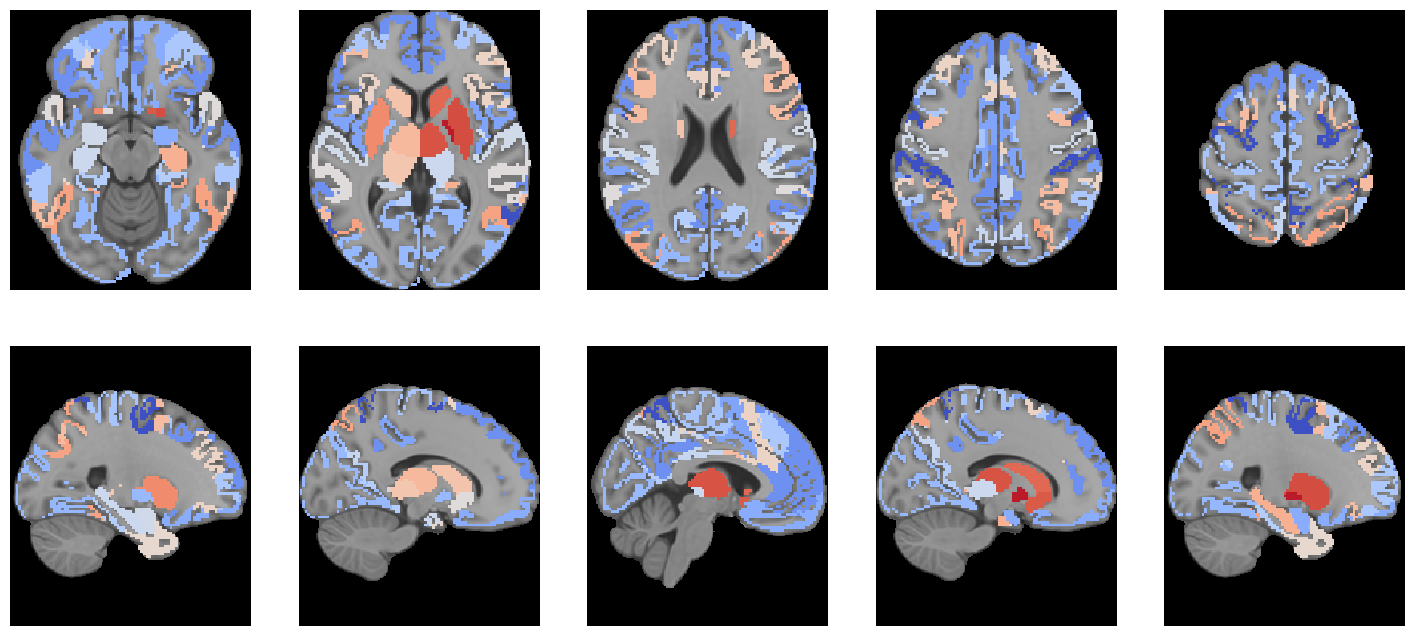

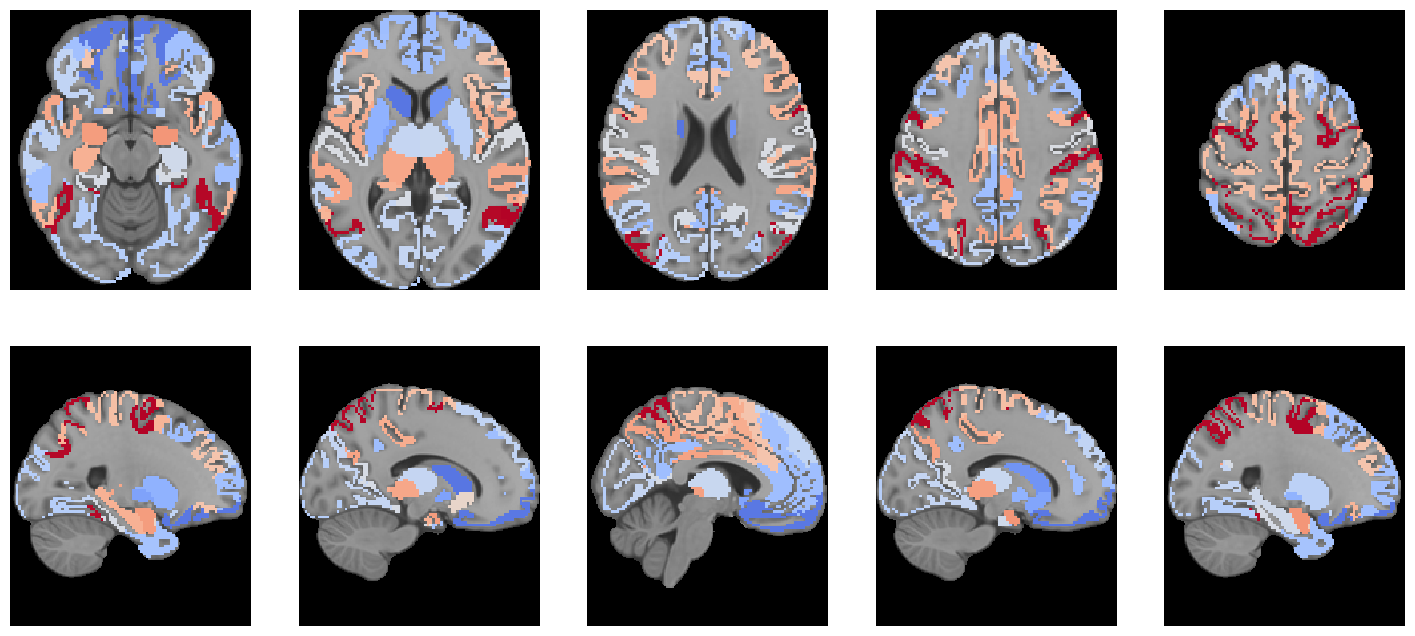

In [9]:
# Another way of graphing

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import plotting, datasets
import os

mni_template = datasets.load_mni152_template()

#statename = ['state1', 'state2', 'state3', 'state4', 'state5', 'state6', 'state7', 'state8', 'state9', 'state10']

output_dir_tian = "output_HMM/Brain_state/output_states_tian"
output_dir_yeo = "output_HMM/Brain_state/output_states_yeo"
for stt in range(1, 11): 
    tian_img = nib.load(os.path.join(output_dir_tian, f'state{stt}_tian_raw.nii.gz'))
    tian_data = tian_img.get_fdata()
    yeo_img = nib.load(os.path.join(output_dir_yeo, f'state{stt}_yeo_raw.nii.gz'))
    yeo_data = yeo_img.get_fdata()
    yeo_resampled_img = resample_to_img(yeo_img, tian_img, interpolation='nearest')
    yeo_data_resampled = np.squeeze(yeo_resampled_img.get_fdata())

    combined_data = tian_data + yeo_data_resampled

    combined_img = nib.Nifti1Image(combined_data, tian_img.affine)

    cut_coords_axial = [-14, 4, 22, 40, 58]  # axial
    cut_coords_sagittal = [-25,-15,5,15,25]  # sagittal

    fig, axes = plt.subplots(2, len(cut_coords_axial), figsize=(18, 8))

    for i, coord in enumerate(cut_coords_axial):
        plotting.plot_stat_map(
            combined_img,
            bg_img=mni_template,
            cut_coords=[coord],
            display_mode='z',
            #title=f'Axial z={coord}',
            axes=axes[0, i],
            cmap='coolwarm',
            colorbar=False, 
            vmin=-2,  
            vmax=2,
            black_bg=True,  
            annotate=False
        )

    for i, coord in enumerate(cut_coords_sagittal):
        plotting.plot_stat_map(
            combined_img,
            bg_img=mni_template,
            cut_coords=[coord],
            display_mode='x',
            #title=f'Sagittal x={coord}',
            axes=axes[1, i],
            cmap='coolwarm',
            colorbar=False,  
            vmin=-2,  
            vmax=2,
            black_bg=True,
            annotate=False
        )

    plt.show()


C:\Users\28694\AppData\Local\Temp\ipykernel_41804\2999936241.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm')


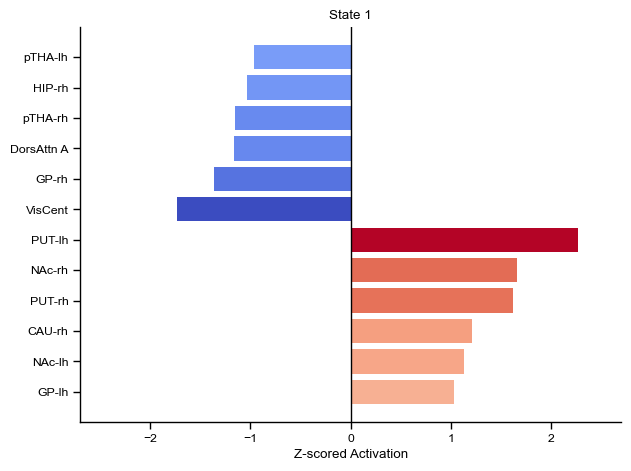

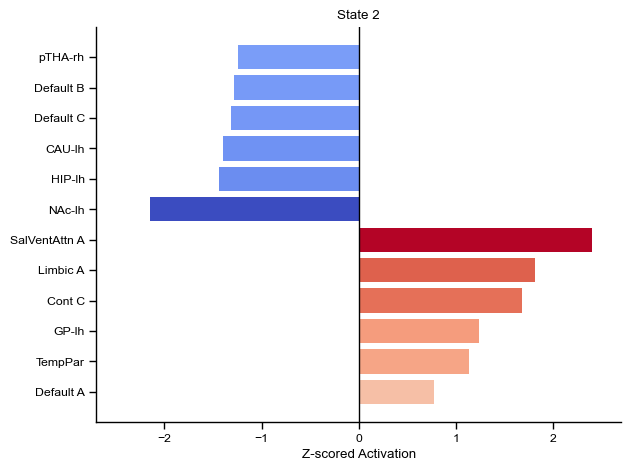

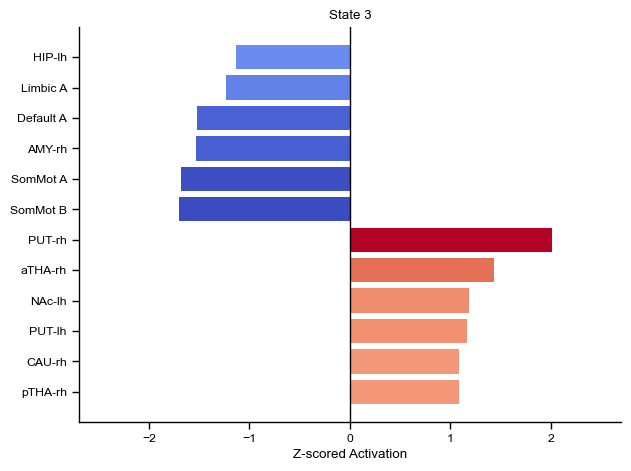

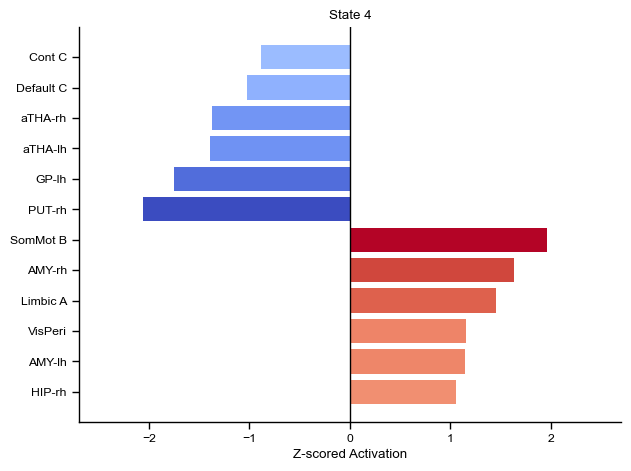

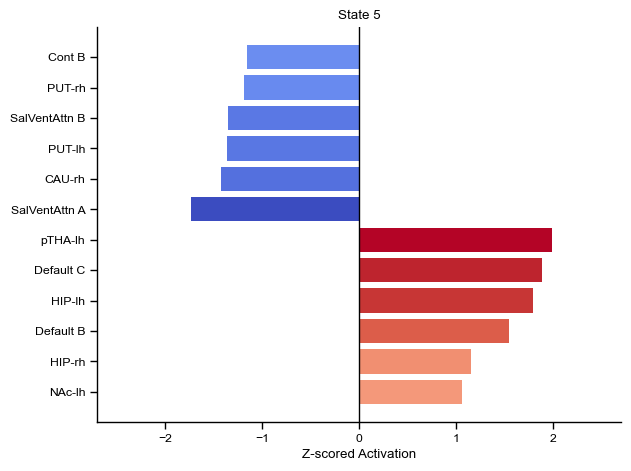

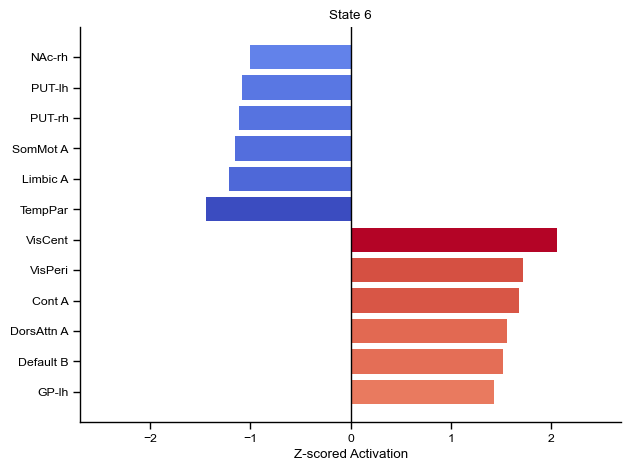

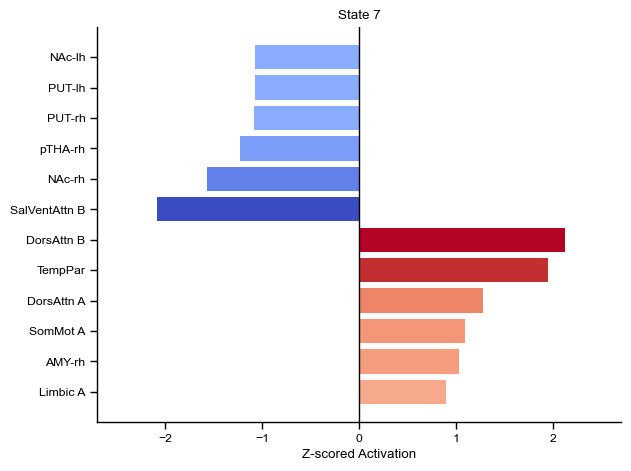

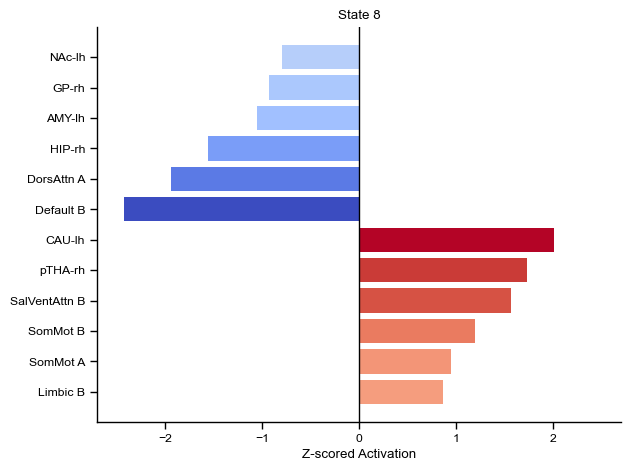

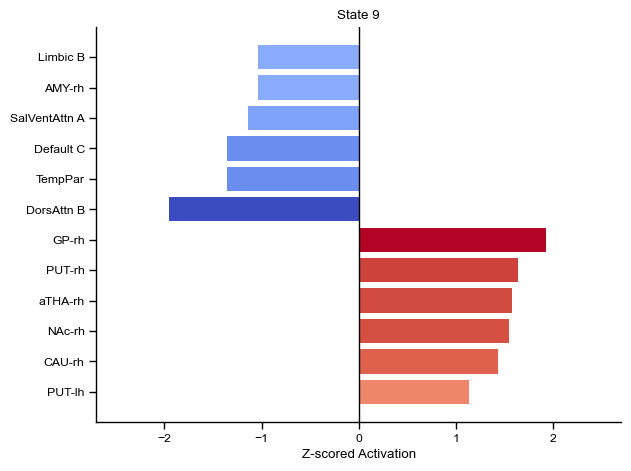

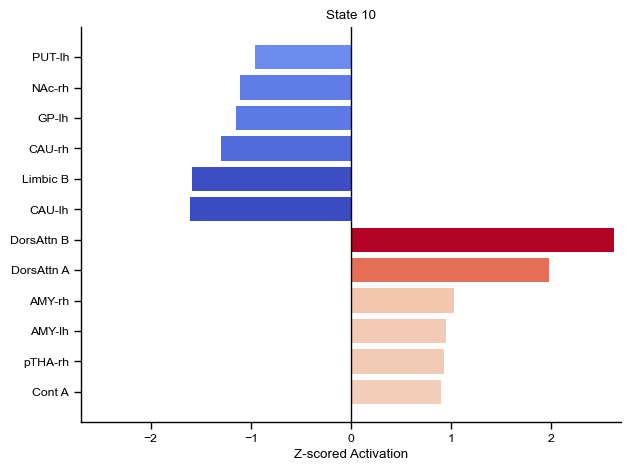

In [10]:
plt.rcParams['font.family'] = 'Arial'

brain_regions = ['HIP-rh', 'AMY-rh', 'pTHA-rh', 'aTHA-rh', 'NAc-rh', 'GP-rh', 'PUT-rh', 'CAU-rh',
                 'HIP-lh', 'AMY-lh', 'pTHA-lh', 'aTHA-lh', 'NAc-lh', 'GP-lh', 'PUT-lh', 'CAU-lh',
                 'VisCent', 'VisPeri', 'SomMot A', 'SomMot B', 'DorsAttn A', 'DorsAttn B',
                 'SalVentAttn A', 'SalVentAttn B', 'Limbic A', 'Limbic B', 'Cont A', 'Cont B', 'Cont C',
                 'Default A', 'Default B', 'Default C', 'TempPar']

cmap = cm.get_cmap('coolwarm')

for state_idx in range(state_means.shape[0]):
    state_data = state_means[state_idx, :]
    
    # Get top 6 max and top 6 min indices
    sorted_idx = np.argsort(state_data)
    top6_idx = sorted_idx[-6:]  # Max 6
    bottom6_idx = sorted_idx[:6]  # Min 6
    
    selected_regions = np.array(brain_regions)[np.concatenate([top6_idx, bottom6_idx])]
    selected_vals = np.concatenate([state_data[top6_idx], state_data[bottom6_idx]])
    
    fig, ax = plt.subplots()

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    bars = ax.barh(np.arange(len(selected_vals)), selected_vals, 
                color=cmap((selected_vals - selected_vals.min()) / (selected_vals.max() - selected_vals.min())))

    ax.set_yticks(np.arange(len(selected_vals)))
    ax.set_yticklabels(selected_regions)

    ax.axvline(x=0, color='black', linewidth=1)

    ax.set_xlabel('Z-scored Activation')
    ax.set_title(f'State {state_idx+1}')

    ax.set_xlim([-2.7, 2.7])
    plt.tight_layout()

## Step 3: then graph covariance

In [11]:
data = sio.loadmat('output_HMM\Brain_state\covars.mat')
Covars = data['covars']  

Covariance matrices shape: (10, 33, 33)


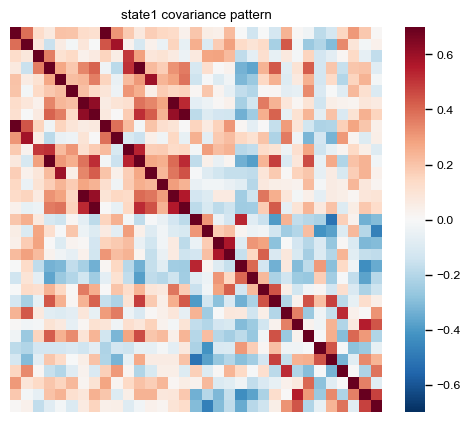

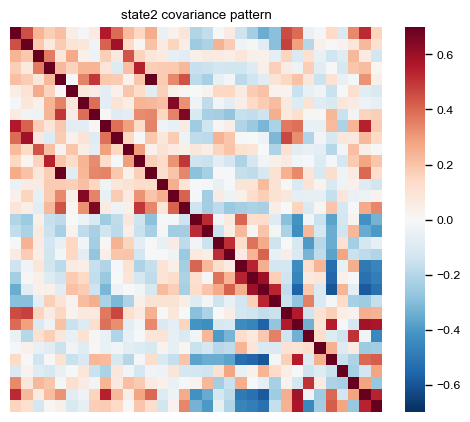

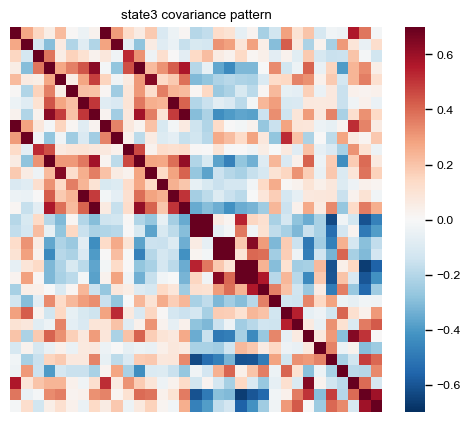

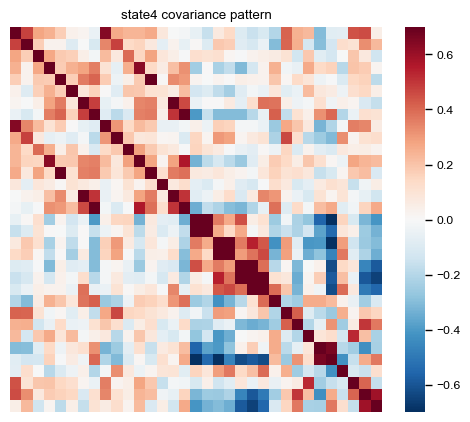

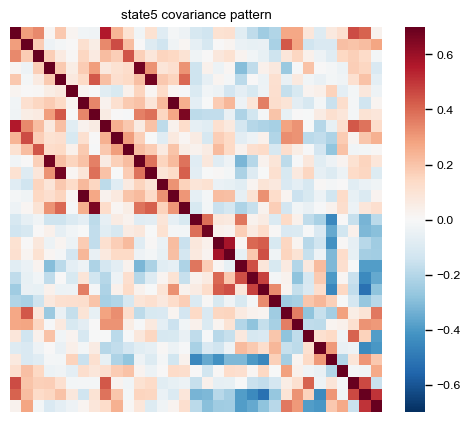

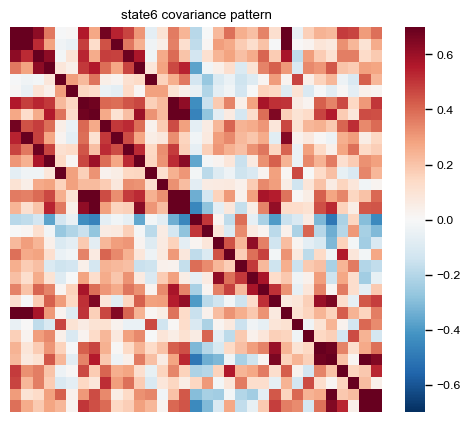

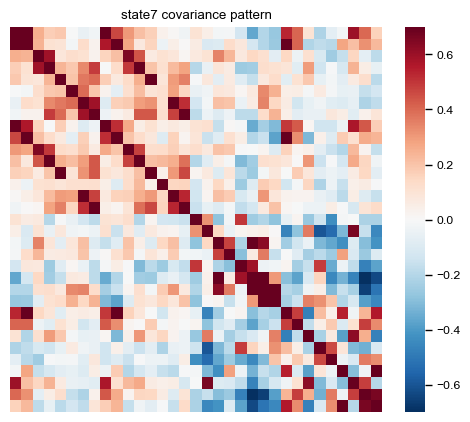

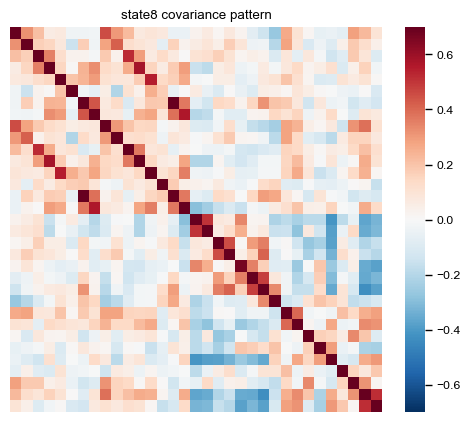

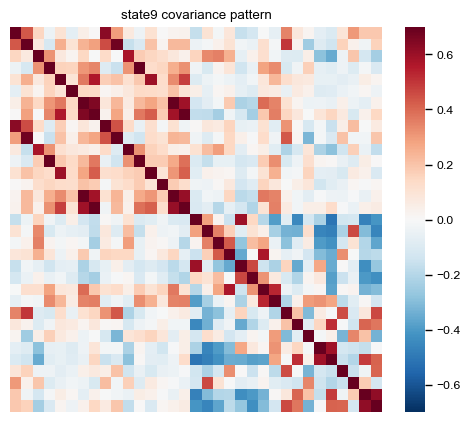

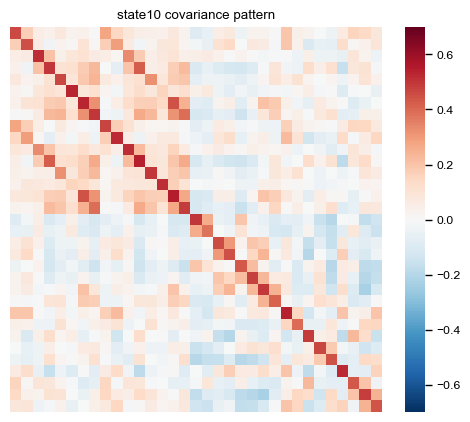

In [12]:
print("Covariance matrices shape:", Covars.shape)

state_names = ['state1', 'state2', 'state3','state4','state5','state6','state7','state8','state9','state10']

for i in range(Covars.shape[0]):
    cbar=True
    plt.figure(figsize=(6, 5))
    sns.heatmap(Covars[i], vmin=-0.7, vmax=0.7, cmap='RdBu_r', cbar=cbar, xticklabels=False, yticklabels=False)
    plt.title(f'{state_names[i]} covariance pattern')
    plt.show()
    